In [9]:
# importa livrarias necessarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style='whitegrid')
np.random.seed(42)

In [10]:
# carrega base de dados
df = pd.read_csv("/Users/claudiojacomassi/Documents/GitHub/Exercicio Aula Aprendizado de Máquina Não Supervisionado 1/vinhos_dataset.csv")

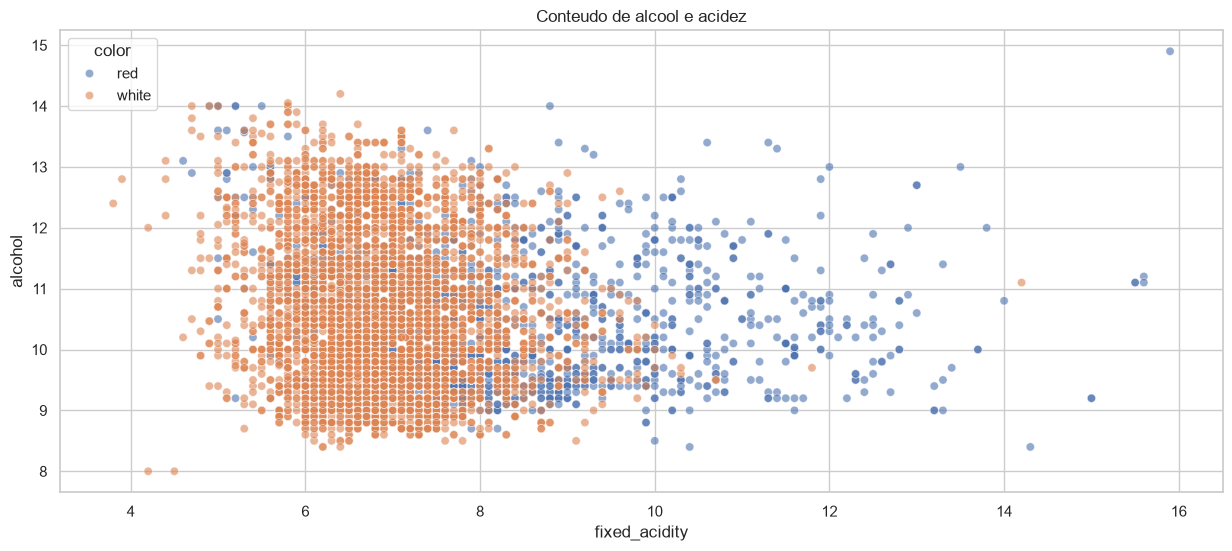

In [11]:
# Grafico conteudo de alcool vs acidez
plt.figure(figsize=(15, 6))
sns.scatterplot(
    data=df,
    x='fixed_acidity',
    y='alcohol',
    hue='color',
    alpha=0.6
)
plt.title('Conteudo de alcool e acidez')
plt
plt.show()

In [12]:
# Definindo os features e mostrando o cabecario e 5 linhas
features = ['fixed_acidity',
    'volatile_acidity',
    'citric_acid',
    'residual_sugar',
    'chlorides',
    'free_sulfur_dioxide',
    'total_sulfur_dioxide',
    'density',
    'pH',
    'sulphates',
    'alcohol']
X = df[features].copy()
X.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [13]:
# Faz o scaler dos "features" usando o standardscaler 
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[ 0.14247327,  2.18883292, -2.19283252, -0.7447781 ,  0.56995782,
        -1.10013986, -1.44635852,  1.03499282,  1.81308951,  0.19309677,
        -0.91546416],
       [ 0.45103572,  3.28223494, -2.19283252, -0.59764007,  1.1979747 ,
        -0.31132009, -0.86246863,  0.70148631, -0.11507303,  0.99957862,
        -0.58006813],
       [ 0.45103572,  2.55330026, -1.91755268, -0.66069923,  1.02669737,
        -0.87476278, -1.09248586,  0.76818761,  0.25811972,  0.79795816,
        -0.58006813],
       [ 3.07381662, -0.36243847,  1.66108525, -0.7447781 ,  0.54141159,
        -0.76207424, -0.98632406,  1.10169412, -0.3638682 ,  0.32751041,
        -0.58006813],
       [ 0.14247327,  2.18883292, -2.19283252, -0.7447781 ,  0.56995782,
        -1.10013986, -1.44635852,  1.03499282,  1.81308951,  0.19309677,
        -0.91546416]])

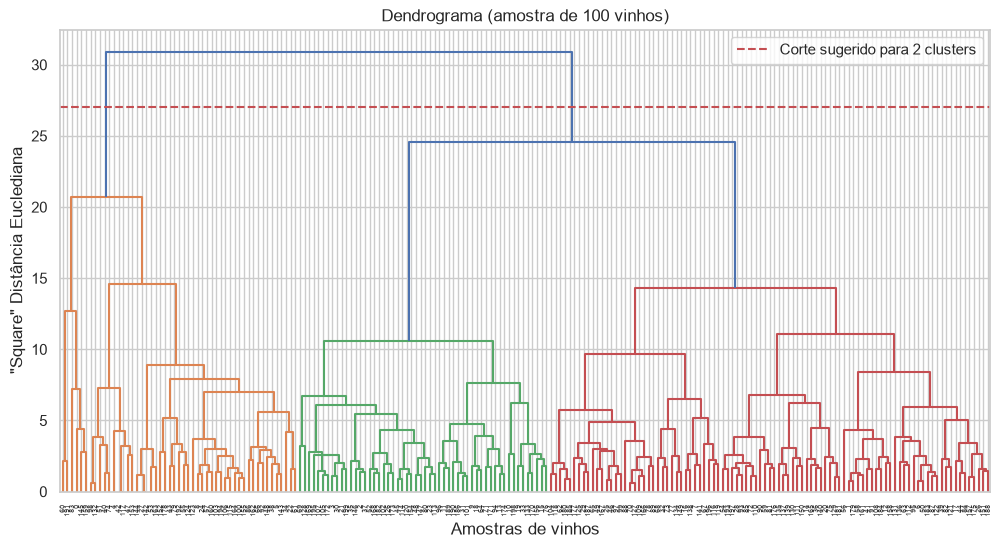

In [72]:
# Vamos visualizar um dendrograma com uma amostra dos dados
# Dendrogramas com muitos pontos ficam ilegíveis
amostra_indices = np.random.choice(len(X), size=200, replace=False)
X_amostra = X_scaled[amostra_indices]

# Calcular linkage para o dendrograma
Z = linkage(X_amostra, method='ward')

# Plotar dendrograma
plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title('Dendrograma (amostra de 100 vinhos)')
plt.xlabel('Amostras de vinhos')
plt.ylabel('"Square" Distância Euclediana')
plt.axhline(y=27, color='r', linestyle='--', label='Corte sugerido para 2 clusters')
plt.legend()
plt.show()

In [65]:
n_clusters_escolhido = 2

linkage_method = 'ward'
hac = AgglomerativeClustering(n_clusters=n_clusters_escolhido, linkage=linkage_method)
clusters = hac.fit_predict(X_scaled)
clusters[:20]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [66]:
hac = AgglomerativeClustering(n_clusters=n_clusters_escolhido, linkage=linkage_method)
clusters_treino = hac.fit_predict(X_scaled)
clusters_treino[:20]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [67]:
#Adicionando os clusters ao DataFrame principal
df['cluster'] = clusters_treino
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color,cluster
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,1


In [68]:
# QUantos vinhos em cada cluster
df['cluster'].value_counts().sort_index()

cluster
0    4756
1    1741
Name: count, dtype: int64

In [69]:
clusters_validos = sorted(df['cluster'].unique())
n_clusters_encontrados = len(clusters_validos)
n_pontos_total = len(df)

print('Número de clusters encontrados:', n_clusters_encontrados)
print('Total de pontos:', n_pontos_total)

Número de clusters encontrados: 2
Total de pontos: 6497


In [70]:
# Avaliação rápida com silhouette score

mask_todos = df['cluster'] >= 0
X_todos = X_scaled[mask_todos]
labels_todos = df.loc[mask_todos, 'cluster']

if len(set(labels_todos)) >= 2:
    sil = silhouette_score(X_todos, labels_todos)
    print('Silhouette Score:', round(sil, 4))
else:
    print('Silhouette Score não pode ser calculado: menos de 2 clusters válidos.')

Silhouette Score: 0.2669


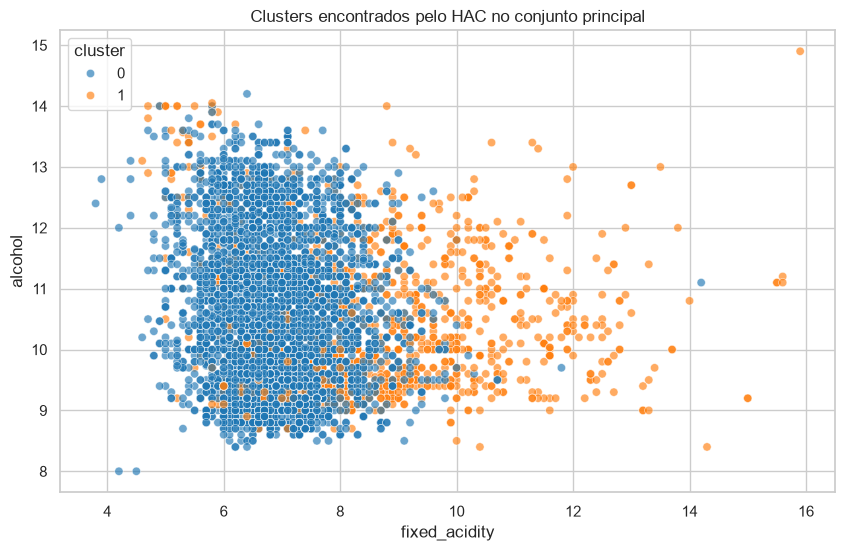

In [71]:
# Visualização dos clusters encontrados no conjunto principal

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='fixed_acidity',
    y='alcohol',
    hue='cluster',
    palette='tab10',
    alpha=0.65
)
plt.title('Clusters encontrados pelo HAC no conjunto principal')
plt.show()